In [3]:
# Data Wrangling 
import numpy as np
import pandas as pd 

# Data Visualisation 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

# Machine Learning Tools 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, mean_squared_error

In [4]:
train_data = pd.read_csv("../data/raw/train_data.csv")
train_data.describe(include='all')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP001002,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


Since gender is of less importance lets replace the missing values with mode

In [5]:
test_data=train_data.copy()


first we are converting nominal values to binary

In [6]:
train_data['Loan_Status']=train_data['Loan_Status'].map({'Y':1,'N':0})
train_data['Education']=train_data['Education'].map({'Graduate':1,'Not Graduate':0})
train_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,1,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,1,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,1,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,0,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,1,No,6000,0.0,141.0,360.0,1.0,Urban,1


In [7]:
train_data.describe(percentiles=[.31,.32])

,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
count,614.000000,614.000000,614.000000,592.000000,600.00000,564.000000,614.000000
mean,0.781759,5403.459283,1621.245798,146.412162,342.00000,0.842199,0.687296
std,0.413389,6109.041673,2926.248369,85.587325,65.12041,0.364878,0.463973
min,0.000000,150.000000,0.000000,9.000000,12.00000,0.000000,0.000000
31%,1.000000,3083.000000,0.000000,109.210000,360.00000,1.000000,0.000000
32%,1.000000,3100.480000,0.000000,110.000000,360.00000,1.000000,1.000000
max,1.000000,81000.000000,41667.000000,700.000000,480.00000,1.000000,1.000000


In [8]:
train_data.describe(include='all')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614.000000,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614.000000
unique,614,2,2,4,NaN,2,NaN,NaN,NaN,NaN,NaN,3,NaN
top,LP001002,Male,Yes,0,NaN,No,NaN,NaN,NaN,NaN,NaN,Semiurban,NaN
freq,1,489,398,345,NaN,500,NaN,NaN,NaN,NaN,NaN,233,NaN
mean,NaN,NaN,NaN,NaN,0.781759,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,0.687296
std,NaN,NaN,NaN,NaN,0.413389,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,0.463973
min,NaN,NaN,NaN,NaN,0.000000,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,0.000000
25%,NaN,NaN,NaN,NaN,1.000000,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,0.000000
50%,NaN,NaN,NaN,NaN,1.000000,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,1.000000
75%,NaN,NaN,NaN,NaN,1.000000,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,1.000000


In [9]:
pd.crosstab(train_data['Property_Area'],train_data['Loan_Status'])

Loan_Status,0,1
Property_Area,,
Rural,69,110
Semiurban,54,179
Urban,69,133


Loan applicant income is from 150 to 81000
Co applicant income is from 0(no co-applicant) to 700
78 percent of people are graduated
69% of people get their loan approved
85% people has very good credit score
Semi urban has the most frequency with 233,nearly 37%of dataset and semiurban has the most chances of getting a loan approved
loan id has no impact on loan status and so it can be removed

In [10]:
#dropping loan_id as it is not useful for prediction
train_data.drop('Loan_ID',axis=1,inplace=True)
test_data.drop('Loan_ID',axis=1,inplace=True)
combined_data=[train_data,test_data]
combined_data[0].head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,1,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,Male,Yes,1,1,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,Male,Yes,0,1,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,Male,Yes,0,0,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,Male,No,0,1,No,6000,0.0,141.0,360.0,1.0,Urban,1


DATA WRANGLING

In [11]:
print(train_data.isnull().sum())
print("-"*50)
print(test_data.isnull().sum())


Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64
--------------------------------------------------
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


There are plenty of missing values and some of them are categorical values so we need to find relation between data and plot data to estimate missing values more accurately.

<Axes: >

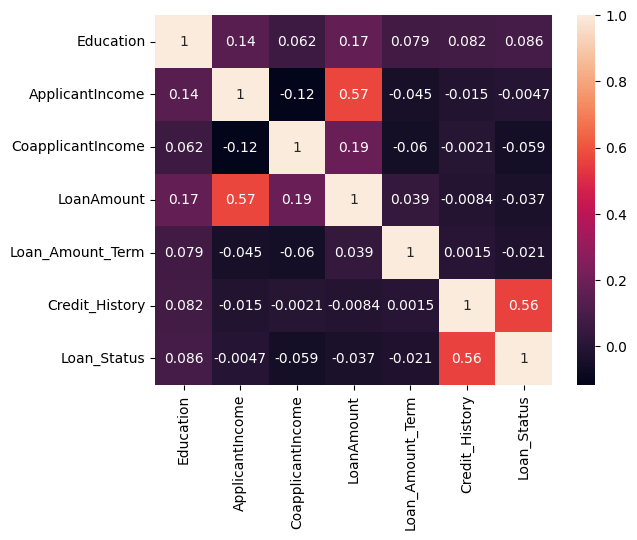

In [12]:
#plotting a correlation heatmap
sns.heatmap(train_data.select_dtypes(include=['number']).corr(), annot=True)

Now lets first fill the missing values of marital status 

In [13]:
pd.crosstab(train_data['Married'],train_data['Loan_Status'])

Loan_Status,0,1
Married,,
No,79,134
Yes,113,285


In [14]:
print(train_data[['Married','ApplicantIncome']].groupby('Married',as_index='False').median())
print(train_data[['Married','ApplicantIncome']].groupby('Married',as_index='False').mean())

         ApplicantIncome
Married                 
No                3750.0
Yes               3854.5
         ApplicantIncome
Married                 
No           4970.384977
Yes          5629.173367


In [15]:
print(train_data[['Married','CoapplicantIncome']].groupby('Married',as_index='False').median())
print(train_data[['Married','CoapplicantIncome']].groupby('Married',as_index='False').mean())

         CoapplicantIncome
Married                   
No                     0.0
Yes                 1625.0
         CoapplicantIncome
Married                   
No             1316.558685
Yes            1794.632965


In [16]:
train_data[train_data['Married'].isnull()]

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
104,Male,NaN,NaN,1,No,3816,754.0,160.0,360.0,1.0,Urban,1
228,Male,NaN,NaN,1,No,4758,0.0,158.0,480.0,1.0,Semiurban,1
435,Female,NaN,NaN,1,No,10047,0.0,NaN,240.0,1.0,Semiurban,1


So there are three missing values,so now we are going to 
1.replace the missing values by 'No' if the coaplicant income is 0.then if this doesn't satisfy then,
2.replace the missing values by 'yes' where income is greater than 5000 and 'no' where income is less than 5000.

In [17]:
train_data.loc[435, 'Married'] = 'No'
train_data.loc[228, 'Married'] = 'No'
train_data.loc[104, 'Married'] = 'No'
print(train_data)

     Gender Married Dependents  Education Self_Employed  ApplicantIncome  \
0      Male      No          0          1            No             5849   
1      Male     Yes          1          1            No             4583   
2      Male     Yes          0          1           Yes             3000   
3      Male     Yes          0          0            No             2583   
4      Male      No          0          1            No             6000   
..      ...     ...        ...        ...           ...              ...   
609  Female      No          0          1            No             2900   
610    Male     Yes         3+          1            No             4106   
611    Male     Yes          1          1            No             8072   
612    Male     Yes          2          1            No             7583   
613  Female      No          0          1           Yes             4583   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0              

In [18]:
print(train_data.isnull().sum())

Gender               13
Married               0
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [19]:
train_data[['Loan_Status','Gender']].groupby(['Gender']).mean()

,Loan_Status
Gender,
Female,0.669643
Male,0.693252


Irrsespective of gender the loan status is approved equally.

In [20]:
train_data[train_data['Gender'].isnull()]

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
23,NaN,Yes,2,0,No,3365,1917.0,112.0,360.0,0.0,Rural,0
126,NaN,Yes,3+,1,No,23803,0.0,370.0,360.0,1.0,Rural,1
171,NaN,Yes,3+,1,No,51763,0.0,700.0,300.0,1.0,Urban,1
188,NaN,Yes,0,1,Yes,674,5296.0,168.0,360.0,1.0,Rural,1
314,NaN,Yes,0,1,No,2473,1843.0,159.0,360.0,1.0,Rural,0
334,NaN,Yes,1,1,Yes,9833,1833.0,182.0,180.0,1.0,Urban,1
460,NaN,Yes,0,1,Yes,2083,4083.0,160.0,360.0,NaN,Semiurban,1
467,NaN,Yes,0,1,No,16692,0.0,110.0,360.0,1.0,Semiurban,1
477,NaN,Yes,2,1,No,2873,1872.0,132.0,360.0,0.0,Semiurban,0
507,NaN,No,0,1,No,3583,0.0,96.0,360.0,1.0,Urban,0


### Handling Missing Values: Gender

- **Observation:**
  - The relationship between `Gender` and `Loan_Status` is weak:
    - Female approval rate ≈ 0.66
    - Male approval rate ≈ 0.69
  - This indicates that gender does not significantly influence loan approval.

- **Assumption:**
  - Missing values in `Gender` are likely random and do not carry strong underlying meaning.

- **Strategy:**
  - Use **mode imputation** (most frequent value) to fill missing entries.

- **Reasoning:**
  - Gender is a **low-impact feature**, so simple imputation is sufficient.
  - Mode preserves the overall distribution of the dataset.
  - Avoids introducing artificial bias or incorrect patterns.

In [21]:
train_data['Gender']=train_data['Gender'].fillna(train_data['Gender'].mode()[0], inplace=True)

/tmp/ipykernel_19360/2259483472.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_data['Gender']=train_data['Gender'].fillna(train_data['Gender'].mode()[0], inplace=True)


In [22]:
train_data.isnull().sum()

Gender                0
Married               0
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [23]:
print(train_data.Dependents.unique())

<StringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str


for doing numerical analysis lets convert 3+ to 3

In [24]:
train_data['Dependents']=train_data['Dependents'].replace('3+','3')
print(train_data.Dependents.unique())

<StringArray>
['0', '1', '2', '3', nan]
Length: 5, dtype: str


We see that the values are string,so lets convert all to integer

In [25]:
train_data['Dependents']=train_data['Dependents'].astype(float)
print(train_data.Dependents.unique())

[ 0.  1.  2.  3. nan]


So basically lets  check if a 'dependent' feature depends on columns 
first married

In [26]:
pd.crosstab(train_data['Dependents'],train_data['Married'])

Married,No,Yes
Dependents,,
0.0,171,174
1.0,23,79
2.0,8,93
3.0,7,44


second coapplicant income

In [27]:
print(train_data[['Dependents','CoapplicantIncome']].groupby(['Dependents']).mean())

            CoapplicantIncome
Dependents                   
0.0               1623.696000
1.0               1426.235294
2.0               1687.245544
3.0               2024.313725


So we can tell that if there is a dependent of 2,3 it is most probably married is yes
so now we are going to replace the missing values of dependents by 2 if (coapplicant income>1623 and coapplicant income<2000 and married is yes) 3 if (coapplicant income>2000 and married is yes) if both conditions are not satisfied then 0

In [28]:
train_data.loc[((train_data['CoapplicantIncome']>1623) & (train_data['CoapplicantIncome']<2000) & (train_data['Married']=='Yes')),'Dependents']=2
train_data.loc[((train_data['CoapplicantIncome']>2000) & (train_data['Married']=='Yes')),'Dependents']=3



In [29]:
train_data['Dependents']=train_data['Dependents'].fillna(train_data['Dependents'].mode()[0], inplace=True) 
print(train_data.isnull().sum())

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


/tmp/ipykernel_19360/439808008.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_data['Dependents']=train_data['Dependents'].fillna(train_data['Dependents'].mode()[0], inplace=True)


Next lets go to self-employed column

In [30]:
train_data['Self_Employed'].unique()

<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

Now when we think of its importance on loan status

In [33]:
pd.crosstab(train_data['Self_Employed'],train_data['Loan_Status'])

Loan_Status,0,1
Self_Employed,,
No,157,343
Yes,26,56


we have found that self_emplyed feature is actually a important thing when deciding loan status

In [34]:
train_data.groupby('Self_Employed')['ApplicantIncome'].mean()

Self_Employed
No     5049.748000
Yes    7380.817073
Name: ApplicantIncome, dtype: float64

In [37]:
train_data['Self_Employed']=train_data['Self_Employed'].fillna(train_data['Self_Employed'].mode()[0])
print(train_data.isnull().sum())

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


Next lets go with LoanAmount,here wihtout no doubt since it deals with numerical lets check if the laonamount is sorted

In [38]:
train_data

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0.0,1,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,Male,Yes,1.0,1,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,Male,Yes,0.0,1,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,Male,Yes,3.0,0,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,Male,No,0.0,1,No,6000,0.0,141.0,360.0,1.0,Urban,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0.0,1,No,2900,0.0,71.0,360.0,1.0,Rural,1
610,Male,Yes,3.0,1,No,4106,0.0,40.0,180.0,1.0,Rural,1
611,Male,Yes,1.0,1,No,8072,240.0,253.0,360.0,1.0,Urban,1
612,Male,Yes,2.0,1,No,7583,0.0,187.0,360.0,1.0,Urban,1


no now loan amount is not sorted,so more imputation techniques are aldready out,next lets find its relation with other features.

In [40]:
train_data.groupby('Dependents')['LoanAmount'].mean()

Dependents
0.0    128.454167
1.0    152.306452
2.0    134.141509
3.0    174.918478
Name: LoanAmount, dtype: float64

In [41]:
train_data.groupby('Loan_Amount_Term')['LoanAmount'].mean()

Loan_Amount_Term
12.0     111.000000
36.0     117.500000
60.0     140.000000
84.0     132.250000
120.0     22.333333
180.0    147.523810
240.0    118.333333
300.0    185.153846
360.0    147.245436
480.0    151.800000
Name: LoanAmount, dtype: float64

In [42]:
train_data.groupby('ApplicantIncome')['LoanAmount'].mean()

ApplicantIncome
150      135.0
210       98.0
416      350.0
645      113.0
674      168.0
         ...  
39147    120.0
39999    600.0
51763    700.0
63337    490.0
81000    360.0
Name: LoanAmount, Length: 505, dtype: float64

We couldn't find any relation between features,so we need to move to the next option of median

In [44]:
train_data['LoanAmount']=train_data['LoanAmount'].fillna(train_data['LoanAmount'].median())
train_data.isnull().sum()

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [46]:
train_data['Loan_Amount_Term']=train_data['Loan_Amount_Term'].fillna(train_data['Loan_Amount_Term'].mode()[0])
train_data.isnull().sum()

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [47]:
train_data.corr(numeric_only=True)['Credit_History']

Dependents          -0.036596
Education            0.081822
ApplicantIncome     -0.014715
CoapplicantIncome   -0.002056
LoanAmount          -0.007543
Loan_Amount_Term    -0.003735
Credit_History       1.000000
Loan_Status          0.561678
Name: Credit_History, dtype: float64

<Axes: xlabel='Credit_History', ylabel='count'>

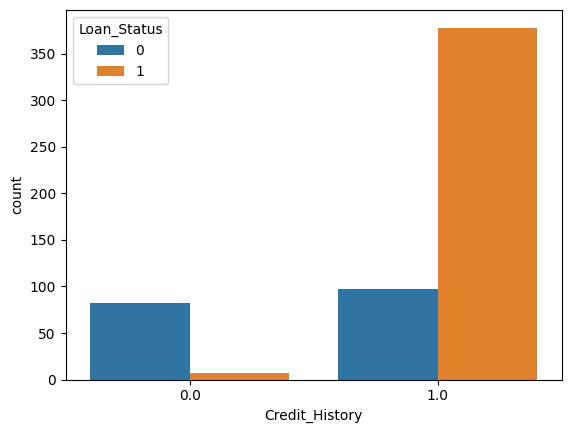

In [48]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=train_data)

In [50]:
train_data['Credit_History']=train_data['Credit_History'].fillna(train_data['Credit_History'].mode()[0])
print(train_data.isnull().sum())

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64
